In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [7]:
df = pd.read_csv(r"/Users/loganheydt/Desktop/Data/GitHub/Titanic-Prediction/Data/train.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
drop_cols = ['PassengerId', 'Name', 'Cabin']
one_hot_cols = ['Sex', 'Embarked']
impute_cols = ['Age']

# Need to drop the 2 null embarked 

In [10]:
# Dropped 2 null Embarked
modeling_df = df.dropna(subset=['Embarked'])


# Imputed Age
imputer = SimpleImputer(strategy='mean')
imputer.fit(modeling_df[impute_cols])
x_imputed = imputer.transform(modeling_df[impute_cols])
modeling_df[impute_cols] = pd.DataFrame(x_imputed, columns=impute_cols, index=modeling_df.index)

# Dropped unneccesary columns
modeling_df.drop(columns=drop_cols)

/var/folders/pv/sb376m3d1d3f50fwn0bcgwkh0000gn/T/ipykernel_18348/4179953622.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  modeling_df[impute_cols] = pd.DataFrame(x_imputed, columns=impute_cols, index=modeling_df.index)


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

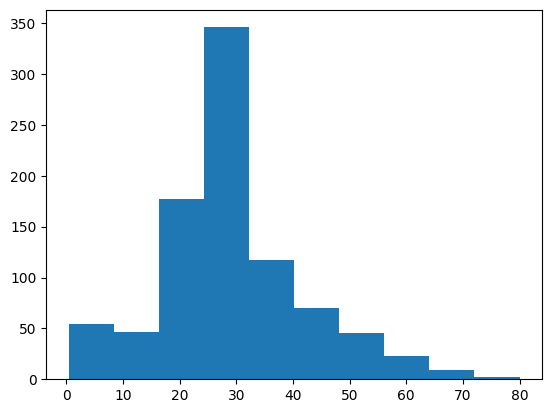

In [14]:
plt.hist(modeling_df['Age'])
plt.show()

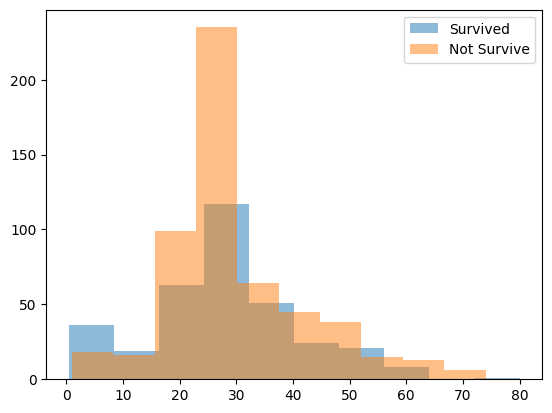

In [13]:
survived = modeling_df[modeling_df['Survived'] == 1]
not_survive = modeling_df[modeling_df['Survived'] == 0]

plt.hist(survived['Age'], alpha=.5, label='Survived')
plt.hist(not_survive['Age'], alpha=.5,  label= 'Not Survive')
plt.legend()
plt.show()